# Análisis exploratorio de datos (EDA) — Airbnb Bogotá

**Taller evaluativo 2 · Inteligencia de Negocios**

**Integrantes:** Mateo Orozco Oquendo, David Stiven Diaz, Jhon Fredy Gomez y Luis Alfredo Gomez · **Responsable del EDA:** Luis Alfredo Gomez

Este notebook explora los datos de Inside Airbnb para Bogotá (scrape del 21-jun-2026) **leyéndolos desde
la base MongoDB local `airbnb_bogota`** mediante la clase `Extraccion` del proceso ETL (no se leen los CSV).
El objetivo es entender la estructura, la calidad y la distribución de los datos para **justificar cada
transformación** que implementa la clase `Transformacion` (`src/transformacion.py`).

Contenido:
1. Extracción desde MongoDB
2. Entendimiento general de los datos (2.1)
3. Calidad de los datos: nulos, duplicados y atípicos (2.2)
4. Posibles transformaciones (2.3)
5. Análisis visual y documentación de hallazgos (2.4)

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from src.extraccion import Extraccion

DIR_FIGURAS = RAIZ / "informe" / "figuras"
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

metricas = {}  # métricas que se reutilizan en el informe PDF

def guardar(fig, nombre):
    """Guarda la figura en informe/figuras para usarla en el informe."""
    fig.savefig(DIR_FIGURAS / f"{nombre}.png", dpi=120, bbox_inches="tight")

def cop(x):
    return f"${x:,.0f}".replace(",", ".")

## 1. Extracción desde MongoDB

Se usa la clase `Extraccion`, que se conecta a `mongodb://localhost:27017`, consulta cada colección y la
convierte en DataFrame (registrando la conexión y los conteos en `logs/`).

In [2]:
with Extraccion() as ext:
    print("Colecciones:", ext.listar_colecciones())
    datos = ext.extraer_todo()

listings, reviews, calendar = datos["listings"], datos["reviews"], datos["calendar"]
for nombre, df in datos.items():
    print(f"{nombre:<9} {df.shape[0]:>10,} registros  {df.shape[1]:>3} columnas")
metricas["registros"] = {k: int(len(v)) for k, v in datos.items()}
metricas["columnas"] = {k: int(v.shape[1]) for k, v in datos.items()}

2026-10-03 09:26:02 | INFO | etl | Archivo de log de la ejecución: C:\Users\mathe\Downloads\Negocios\Evaluativo 2\proyecto\logs\log_20261003_0926.txt


2026-10-03 09:26:02 | INFO | etl.extraccion | Conexión establecida con MongoDB en mongodb://localhost:27017, base de datos 'airbnb_bogota'


2026-10-03 09:26:02 | INFO | etl.extraccion | Colecciones disponibles: ['Calendar', 'Listings', 'Reviews']


Colecciones: ['Calendar', 'Listings', 'Reviews']


2026-10-03 09:26:06 | INFO | etl.extraccion | Colección 'Listings': 19187 registros extraídos, 77 columnas (3.1 s)


2026-10-03 09:26:14 | INFO | etl.extraccion | Colección 'Reviews': 527731 registros extraídos, 6 columnas (8.2 s)


2026-10-03 09:27:08 | INFO | etl.extraccion | Colección 'Calendar': 7003255 registros extraídos, 5 columnas (54.3 s)


2026-10-03 09:27:09 | INFO | etl.extraccion | Extracción finalizada: 7550173 registros en total


2026-10-03 09:27:09 | INFO | etl.extraccion | Conexión a MongoDB cerrada


listings      19,187 registros   77 columnas
reviews      527,731 registros    6 columnas
calendar   7,003,255 registros    5 columnas


## 2.1 Entendimiento general de los datos

### Listings (alojamientos)

In [3]:
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_is_superhost,...,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,bathrooms
0,27841,https://www.airbnb.com/rooms/27841,20260621155658,2026-06-22,city scrape,Rosales Luxury Large 2BR Boutique Apt,Amazing bright 135m2 (1350 sq ft) apartment l...,https://a0.muscache.com/pictures/38377482/1df3...,113734,https://www.airbnb.com/users/show/113734,1462509905126026119,https://www.airbnb.com/users/profile/146250990...,Marcela,16,1,15.0,5.0,"Bogota, Colombia","I am an Architect and Urban Planner ,with my o...",t,...,0,2,112,31840929.0,2010-10-06,2025-09-14,4.87,4.84,4.91,4.93,4.81,4.93,4.81,112727.0,3,3,0,0,0.24,NaN
1,65762,https://www.airbnb.com/rooms/65762,20260621155658,2026-06-22,city scrape,Apartaestudios La Candelaria,"In Bogota's historic center, near museums, res...",https://a0.muscache.com/pictures/miso/Hosting-...,321447,https://www.airbnb.com/users/show/321447,1462515641808590179,https://www.airbnb.com/users/profile/146251564...,Teresa,15,6,15.0,5.0,"Bogotá, Colombia",I'm a person that is always looking to enrich ...,t,...,67,1,0,0.0,2012-02-18,2025-04-28,4.75,4.67,4.81,4.91,4.73,4.79,4.70,100613.0,24,22,2,0,0.19,1.0
2,138660,https://www.airbnb.com/rooms/138660,20260621155658,2026-06-22,city scrape,Excelent Studio ROSALES/ ZONA G,Ideal place if you want to settle down in Bogo...,https://a0.muscache.com/pictures/24594394/1ace...,676823,https://www.airbnb.com/users/show/676823,1462513470872353935,https://www.airbnb.com/users/profile/146251347...,Carlos,15,0,15.0,0.0,"Bogota, Colombia","Colombian who loves to travel, discover and me...",f,...,164,0,0,0.0,2013-07-08,2018-10-21,4.43,4.68,4.14,4.77,4.77,4.91,4.41,NaN,1,1,0,0,0.14,1.0
3,178850,https://www.airbnb.com/rooms/178850,20260621155658,2026-06-22,city scrape,"MODERN APARTMENT, 3 ROOMS, 4 PAX",NaN,https://a0.muscache.com/pictures/22dabfab-c264...,498646,https://www.airbnb.com/users/show/498646,1462512225806609907,https://www.airbnb.com/users/profile/146251222...,Irma,15,2,15.0,0.0,"Madrid, Spain",BUEN DIA\r\nSOY IRMA TORRES VIVO EN MADRID ESP...,f,...,181,0,0,0.0,2019-02-26,2019-12-01,5.00,5.00,5.00,5.00,5.00,4.67,5.00,NaN,2,2,0,0,0.03,2.0
4,289669,https://www.airbnb.com/rooms/289669,20260621155658,2026-06-22,city scrape,Room near to everything you need in Bogotá!,My house is located in one of the most iconic ...,https://a0.muscache.com/pictures/hosting/Hosti...,1503758,https://www.airbnb.com/users/show/1503758,1462518513336962526,https://www.airbnb.com/users/profile/146251851...,Daniel,14,6,14.0,6.0,"Bogota, Colombia","I am crazy about motorcycles, I love to ride m...",t,...,145,1,8,658086.0,2012-04-08,2025-10-12,4.50,3.50,4.50,5.00,5.00,4.50,4.00,214760.0,3,0,3,0,0.01,1.0


In [4]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 19187 entries, 0 to 19186
Data columns (total 77 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            19187 non-null  int64  
 1   listing_url                                   19187 non-null  str    
 2   scrape_id                                     19187 non-null  int64  
 3   last_scraped                                  19187 non-null  str    
 4   source                                        19187 non-null  str    
 5   name                                          19187 non-null  str    
 6   description                                   18664 non-null  str    
 7   picture_url                                   19187 non-null  str    
 8   host_id                                       19187 non-null  int64  
 9   host_url                                      19187 non-null  str    
 1

In [5]:
relevantes = ["price", "room_type", "neighbourhood_cleansed", "accommodates", "bedrooms", "beds",
              "bathrooms", "minimum_nights", "availability_365", "number_of_reviews",
              "review_scores_rating", "estimated_occupancy_l365d", "host_is_superhost"]
listings[relevantes].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,18992,10270,"$171,177.00",130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
room_type,19187,4,Entire home/apt,13865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_cleansed,19187,20,Chapinero,5097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,19187.0,NaN,NaN,NaN,3.105697,2.088394,1.0,2.0,2.0,4.0,16.0
bedrooms,16228.0,NaN,NaN,NaN,1.54067,1.601175,1.0,1.0,1.0,2.0,50.0
beds,18896.0,NaN,NaN,NaN,1.945703,2.094844,1.0,1.0,1.0,2.0,50.0
bathrooms,18121.0,NaN,NaN,NaN,1.419817,1.376452,0.5,1.0,1.0,1.5,50.0
minimum_nights,19183.0,NaN,NaN,NaN,6.979878,10.993985,1.0,1.0,1.0,3.0,32.0
availability_365,19187.0,NaN,NaN,NaN,306.947725,82.073601,0.0,269.0,349.0,363.0,365.0
number_of_reviews,19187.0,NaN,NaN,NaN,27.504612,74.004586,0.0,1.0,8.0,31.0,6162.0


**Lectura.** Cada fila es un alojamiento (19.187) y la tabla tiene 77 columnas. Mezcla datos del anuncio
(nombre, descripción, tipo de habitación, capacidad), del anfitrión (`host_*`), de la ubicación (barrio,
latitud/longitud), de la disponibilidad (`availability_*`) y de las reseñas (`review_scores_*`).
Ya en `info()` se ven problemas de tipos:

- `price` es **texto** (`"$284,294.01"`) y no un número.
- Los booleanos vienen como `'t'`/`'f'`.
- Las fechas (`last_scraped`, `first_review`...) son strings.
- `amenities` y `price_quote_raw` son **estructuras anidadas en JSON** guardadas como texto.

### Reviews (reseñas)

In [6]:
reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,27841,113163,2010-10-06,121485,Paul,I really enjoyed staying at Marcela's place. I...
1,27841,143106,2010-11-22,288940,Vic,"I, Arrived an hour late from the airport. Mar..."
2,27841,172475,2011-01-19,98406,Matt,"Wonderful hosts, beautiful spacious apartment,..."
3,27841,225796,2011-04-13,471115,Tiffany,Marcela was a lovely and gracious host. She me...
4,27841,952928,2012-02-27,1098411,Sarah,Marcela is the perfect host and has a gorgeuos...


In [7]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 527731 entries, 0 to 527730
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   listing_id     527731 non-null  int64
 1   id             527731 non-null  int64
 2   date           527731 non-null  str  
 3   reviewer_id    527731 non-null  int64
 4   reviewer_name  527731 non-null  str  
 5   comments       527540 non-null  str  
dtypes: int64(3), str(3)
memory usage: 24.2 MB


In [8]:
resumen_rev = reviews.assign(longitud=reviews["comments"].str.len())
display(resumen_rev[["listing_id", "reviewer_id", "longitud"]].describe().round(1))
print("Alojamientos con reseñas:", f"{reviews['listing_id'].nunique():,}",
      "· revisores distintos:", f"{reviews['reviewer_id'].nunique():,}")
print("Rango de fechas:", reviews["date"].min(), "->", reviews["date"].max())

,listing_id,reviewer_id,longitud
count,5.277310e+05,5.277310e+05,527540.0
mean,6.881048e+17,5.397614e+15,160.8
std,5.681957e+17,9.509053e+16,183.4
min,2.784100e+04,1.530000e+02,1.0
25%,4.376747e+07,1.225224e+08,45.0
50%,8.125132e+17,2.911771e+08,103.0
75%,1.185818e+18,4.783537e+08,206.0
max,1.711111e+18,1.711693e+18,5632.0


Alojamientos con reseñas: 14,922 · revisores distintos: 371,567


Rango de fechas: 2010-10-06 -> 2026-06-21


**Lectura.** Hay 527.731 reseñas, cada una con `listing_id`, fecha, revisor y comentario libre. `date` es texto,
y los comentarios contienen etiquetas HTML (`<br/>`) y saltos de línea, como se verá en 2.3.

### Calendar (calendario)

In [9]:
calendar.head()

,listing_id,date,available,minimum_nights,maximum_nights
0,15410909,2026-06-22,f,2,1125
1,15410909,2026-06-23,f,2,1125
2,15410909,2026-06-24,f,2,1125
3,15410909,2026-06-25,t,2,1125
4,15410909,2026-06-26,t,2,1125


In [10]:
calendar.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 7003255 entries, 0 to 7003254
Data columns (total 5 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   listing_id      7003255 non-null  int64
 1   date            7003255 non-null  str  
 2   available       7003255 non-null  str  
 3   minimum_nights  7003255 non-null  int64
 4   maximum_nights  7003255 non-null  int64
dtypes: int64(3), str(2)
memory usage: 267.2 MB


In [11]:
calendar[['minimum_nights', 'maximum_nights']].describe().round(1)

,minimum_nights,maximum_nights
count,7003255.0,7.003255e+06
mean,7.3,4.477846e+05
std,11.7,3.098228e+07
min,1.0,1.000000e+00
25%,1.0,3.650000e+02
50%,2.0,3.650000e+02
75%,4.0,1.125000e+03
max,365.0,2.147484e+09


In [12]:
print("Rango de fechas:", calendar["date"].min(), "->", calendar["date"].max())
print("Alojamientos en el calendario:", calendar["listing_id"].nunique())
print("Días por alojamiento:", calendar.groupby("listing_id").size().describe()[["min", "max"]].to_dict())
calendar["available"].value_counts(normalize=True)

Rango de fechas: 2026-06-21 -> 2027-06-21
Alojamientos en el calendario: 19187


Días por alojamiento: {'min': 365.0, 'max': 365.0}


available
t    0.841154
f    0.158846
Name: proportion, dtype: float64

**Lectura.** El calendario tiene **7.003.255 filas**: una por alojamiento y día durante los próximos 365 días
(21-jun-2026 a 21-jun-2027) para los 19.187 alojamientos. En esta versión del dataset **no incluye el
precio diario**: solo trae `available` (`t`/`f`) y las noches mínimas y máximas. Por su granularidad conviene
resumirlo por mes y por semana para analizarlo y para exportarlo a Excel, que admite como máximo 1.048.576
filas por hoja.

## 2.2 Calidad de los datos

### Valores nulos o faltantes

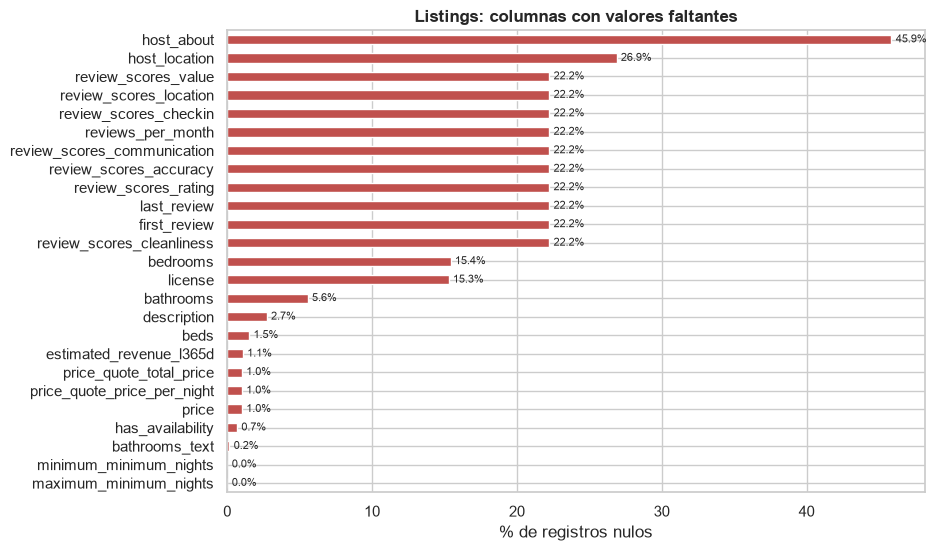

In [13]:
nulos = (listings.isna().mean() * 100).sort_values(ascending=False)
nulos = nulos[nulos > 0]
fig, ax = plt.subplots(figsize=(9, 6))
nulos.head(25).sort_values().plot.barh(ax=ax, color="#c0504d")
ax.set_xlabel("% de registros nulos")
ax.set_title("Listings: columnas con valores faltantes")
for i, v in enumerate(nulos.head(25).sort_values()):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)
guardar(fig, "01_nulos_listings")
plt.show()
metricas["nulos_listings_pct"] = nulos.round(2).to_dict()

In [14]:
print("Reviews  - nulos por columna:", reviews.isna().sum().to_dict())
print("Calendar - nulos por columna:", calendar.isna().sum().to_dict())

Reviews  - nulos por columna: {'listing_id': 0, 'id': 0, 'date': 0, 'reviewer_id': 0, 'reviewer_name': 0, 'comments': 191}


Calendar - nulos por columna: {'listing_id': 0, 'date': 0, 'available': 0, 'minimum_nights': 0, 'maximum_nights': 0}


**Interpretación de los nulos.**

| Columna(s) | % nulos | Significado | Decisión en `Transformacion` |
|---|---|---|---|
| `review_scores_*`, `first_review`, `last_review`, `reviews_per_month` | 22,2 % | El alojamiento **no tiene reseñas** (el porcentaje coincide en todas) | Las calificaciones se dejan nulas (no se inventan), se agrega el flag `tiene_reviews` y `reviews_per_month` pasa a 0 |
| `host_about`, `host_location` | 45,9 % / 26,9 % | El anfitrión no llenó su perfil | Pasan a `"Sin información"` |
| `bedrooms` | 15,4 % | Estudios o anuncios sin el dato | Mediana por `room_type` |
| `license` | 15,3 % | Alojamientos **sin Registro Nacional de Turismo (RNT)** | Pasa a `"Sin registro"` + flag `tiene_licencia` |
| `bathrooms` | 5,6 % | El dato sí está en `bathrooms_text` (`"1 shared bath"`) | Se completa desde el texto |
| `price` | 1,0 % (195) | Anuncio sin precio publicado | **Se conserva** con categoría `"Sin precio"` y se registra un WARNING |
| `description`, `beds`, `has_availability` | < 3 % | Campos opcionales | Texto por defecto, mediana o deducción desde `availability_365` |

Además, **13 columnas del esquema de Inside Airbnb llegan 100 % vacías** en este scrape y por eso
MongoDB ni siquiera las almacenó (el archivo original tiene 90 columnas y la colección `Listings` guarda 77):
`host_since`, `host_response_time`, `host_response_rate`, `host_acceptance_rate`, `host_verifications`,
`host_neighbourhood`, `host_total_listings_count`, `host_thumbnail_url`, `neighbourhood`,
`neighbourhood_group_cleansed`, `neighborhood_overview`, `calendar_updated` e `instant_bookable`.
Así, **la información de tiempo de respuesta del anfitrión no está disponible** para el análisis.
`Reviews` solo tiene 191 comentarios vacíos y `Calendar` no tiene nulos.

### Registros duplicados

In [15]:
duplicados = {
    "listings (id)": int(listings["id"].duplicated().sum()),
    "listings (fila completa)": int(listings.duplicated().sum()),
    "reviews (id)": int(reviews["id"].duplicated().sum()),
    "reviews (fila completa)": int(reviews.duplicated().sum()),
    "calendar (listing_id + date)": int(calendar.duplicated(["listing_id", "date"]).sum()),
}
metricas["duplicados"] = duplicados
pd.Series(duplicados, name="duplicados").to_frame()

,duplicados
listings (id),0
listings (fila completa),0
reviews (id),0
reviews (fila completa),0
calendar (listing_id + date),0


**¿Es necesario eliminar duplicados?** En esta extracción **no hay duplicados**, ni por clave de negocio ni por
fila completa. Aun así, `Transformacion.limpiar_duplicados` se mantiene en el pipeline usando la **clave
natural** de cada tabla (`id`, `id` y `listing_id+date`). Una recarga parcial de MongoDB o un scrape repetido
podría duplicar registros, y un duplicado en el calendario inflaría la disponibilidad. El paso queda en el
log con 0 eliminados, lo que también sirve como evidencia de calidad.

### Valores atípicos: `price`, `minimum_nights`, `availability_365`

In [16]:
precio = pd.to_numeric(listings["price"].str.replace(r"[\$,]", "", regex=True), errors="coerce")
q1, q3 = precio.quantile([0.25, 0.75])
lim_sup = q3 + 1.5 * (q3 - q1)
print(precio.describe(percentiles=[.01, .25, .5, .75, .9, .95, .99]).apply(cop))
print(f"\nLímite superior IQR: {cop(lim_sup)}  ->  {(precio > lim_sup).sum()} alojamientos atípicos "
      f"({(precio > lim_sup).mean():.1%})")
print(f"Precios > $1.000.000: {(precio > 1e6).sum()}   > $10.000.000: {(precio > 1e7).sum()}")
metricas["precio"] = {"mediana": float(precio.median()), "media": float(precio.mean()),
                      "q1": float(q1), "q3": float(q3), "p99": float(precio.quantile(.99)),
                      "max": float(precio.max()), "limite_iqr": float(lim_sup),
                      "atipicos_iqr": int((precio > lim_sup).sum()), "mayor_10M": int((precio > 1e7).sum()),
                      "sin_precio": int(precio.isna().sum())}
listings.assign(precio=precio).nlargest(5, "precio")[["id", "name", "room_type", "accommodates", "precio"]]

count         $18.992
mean         $446.027
std        $8.829.057
min           $19.181
1%            $37.610
25%          $110.000
50%          $161.460
75%          $230.346
90%          $359.471
95%          $497.580
99%        $1.330.087
max      $448.176.567
Name: price, dtype: str

Límite superior IQR: $410.866  ->  1410 alojamientos atípicos (7.3%)
Precios > $1.000.000: 305   > $10.000.000: 27


,id,name,room_type,accommodates,precio
17185,1629245377389583455,casa Q Iuniq - Boutique,Entire home/apt,2,448176567.0
17227,1631561754372485139,casa Q Iuniq- Boutique,Private room,2,421287834.0
17238,1632658392056259396,casa Q Iuniq - Boutique,Private room,2,421287834.0
17240,1632680823682299581,casa Q Iuniq - Boutique,Private room,4,421287834.0
17241,1632687908999942806,Casa Q Iuniq - Boutique,Private room,2,418047397.0


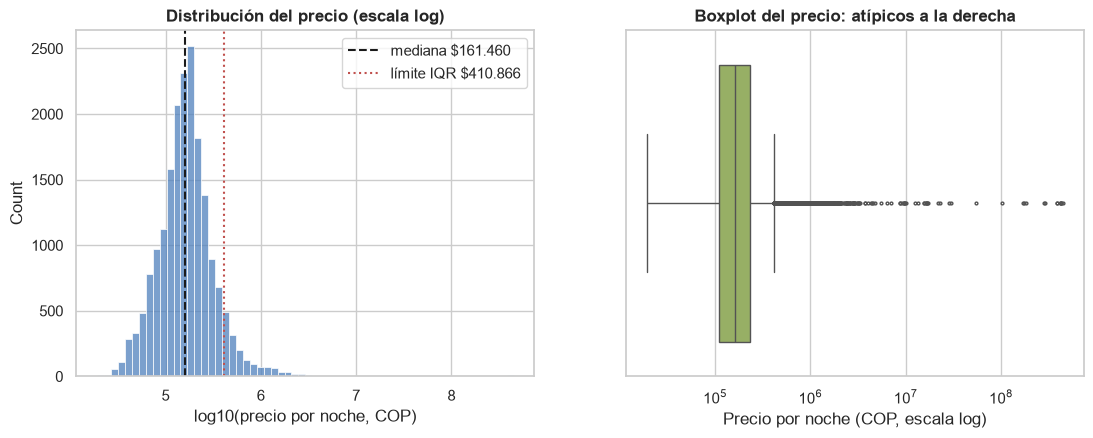

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(np.log10(precio.dropna()), bins=60, ax=axes[0], color="#4f81bd")
axes[0].axvline(np.log10(precio.median()), color="k", ls="--", label=f"mediana {cop(precio.median())}")
axes[0].axvline(np.log10(lim_sup), color="#c0504d", ls=":", label=f"límite IQR {cop(lim_sup)}")
axes[0].set_xlabel("log10(precio por noche, COP)"); axes[0].set_title("Distribución del precio (escala log)")
axes[0].legend()
sns.boxplot(x=precio, ax=axes[1], color="#9bbb59", flierprops={"markersize": 2})
axes[1].set_xscale("log"); axes[1].set_xlabel("Precio por noche (COP, escala log)")
axes[1].set_title("Boxplot del precio: atípicos a la derecha")
guardar(fig, "02_precio_outliers")
plt.show()

**Interpretación del precio.**

- La distribución es **muy asimétrica a la derecha**: la mediana es ≈ $161.000 COP por noche, pero la media
  es ≈ $446.000 porque unos pocos valores extremos la arrastran. La desviación estándar supera los $8,8 millones.
- Con el criterio IQR, todo lo que pasa de ≈ $411.000 es atípico: **1.410 alojamientos (7,3 %)**. Muchos son
  apartamentos de lujo plausibles. En cambio, **27 anuncios superan $10 millones por noche** y el máximo llega
  a $448 millones (un mismo anfitrión, "casa Q Iuniq - Boutique", con habitaciones privadas para 2 personas).
  Eso es claramente un **error de carga del anfitrión**.
- **Decisión:** los atípicos **se marcan** (`es_outlier_precio`) y **no se eliminan**. No hay forma objetiva de
  separar el lujo real del error, y borrar filas haría perder sus reseñas y su calendario. Para los
  promedios conviene usar la mediana o excluir los marcados. Por la misma asimetría, las categorías de precio
  se definen por rangos fijos que siguen los cuartiles y no por la media.

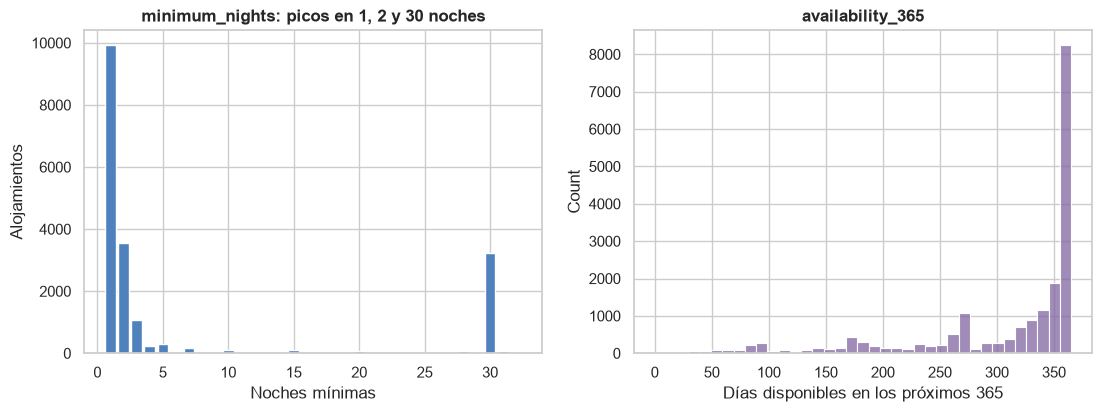

{'count': 19183.0, 'mean': 7.0, 'std': 11.0, 'min': 1.0, '25%': 1.0, '50%': 1.0, '75%': 3.0, 'max': 32.0}
availability_365
(-1, 0]           4
(0, 90]         912
(90, 180]      1356
(180, 270]     2907
(270, 364]    10500
(364, 365]     3508
Name: count, dtype: int64


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
mn = listings["minimum_nights"].value_counts().sort_index()
axes[0].bar(mn.index.astype(int), mn.values, color="#4f81bd")
axes[0].set_xlabel("Noches mínimas"); axes[0].set_ylabel("Alojamientos")
axes[0].set_title("minimum_nights: picos en 1, 2 y 30 noches")
sns.histplot(listings["availability_365"], bins=37, ax=axes[1], color="#8064a2")
axes[1].set_xlabel("Días disponibles en los próximos 365"); axes[1].set_title("availability_365")
guardar(fig, "03_minimum_nights_availability")
plt.show()
print(listings["minimum_nights"].describe().round(1).to_dict())
print(pd.cut(listings["availability_365"], [-1, 0, 90, 180, 270, 364, 365]).value_counts().sort_index())
metricas["minimum_nights"] = {"1": int(mn.get(1, 0)), "2": int(mn.get(2, 0)), "30": int(mn.get(30, 0)),
                              "max": float(listings["minimum_nights"].max())}

**Interpretación de `minimum_nights` y `availability_365`.**

- `minimum_nights` **no tiene atípicos extremos** (máximo 32), algo distinto a otras ciudades donde aparecen
  valores de 1.125. La distribución es trimodal: **1 noche (51,7 %)**, 2 noches (18,5 %) y **30 noches
  (16,9 %)**. El pico en 30 refleja anuncios de **estancia mensual**, una estrategia distinta al alquiler
  turístico de corta estancia. En lugar de un flag de atípico, se crea la variable `es_estancia_larga`
  (≥ 30 noches).
- `availability_365` está dentro del rango válido 0–365, pero **concentrada en valores altos**: 3.508
  alojamientos (18 %) tienen el calendario abierto los 365 días y solo 4 tienen 0 días. Una disponibilidad
  tan alta sugiere baja ocupación o calendarios que el anfitrión no gestiona. Se agrega el flag
  `sin_disponibilidad_anual` y se usa el calendario para medir la disponibilidad mes a mes.

## 2.3 Posibles transformaciones

### Campos anidados: `amenities` y `price_quote_raw`

In [19]:
print("Ejemplo de amenities (texto JSON):\n", listings["amenities"].iloc[2][:300], "...")
listas_amen = listings["amenities"].map(lambda s: json.loads(s) if isinstance(s, str) else [])
conteo_amen = Counter(a for lista in listas_amen for a in lista)
print(f"\nAmenities distintas: {len(conteo_amen):,} · por alojamiento: mediana {listas_amen.str.len().median():.0f}, "
      f"máx {listas_amen.str.len().max()}")
print("\nEjemplo de price_quote_raw (JSON anidado):")
print(json.dumps(json.loads(listings["price_quote_raw"].iloc[0])["quote"], indent=1)[:700])
metricas["amenities_distintas"] = len(conteo_amen)
metricas["amenities_mediana"] = float(listas_amen.str.len().median())

Ejemplo de amenities (texto JSON):
 ["Hot water", "Kitchen", "Self check-in", "TV with standard cable", "Long term stays allowed", "Iron", "Free parking on premises", "Wifi", "Extra pillows and blankets", "Hangers", "Essentials", "Hair dryer", "Bed linens", "Building staff", "Washer", "Elevator"] ...



Amenities distintas: 3,690 · por alojamiento: mediana 26, máx 90

Ejemplo de price_quote_raw (JSON anidado):
{
 "taxes": null,
 "currency": "COP",
 "date_match": null,
 "service_fee": null,
 "total_price": "7960232.40",
 "cleaning_fee": null,
 "is_available": true,
 "discount_amount": "780208.80",
 "price_per_night": "284294.0142857142857142857143",
 "nightly_subtotal": null,
 "discounted_subtotal": "7960232.40",
 "raw_price_line_items": [
  {
   "amount": "8740441.20",
   "item_type": "other",
   "description": "Average monthly price",
   "price_string": "$8,740,441.20\u00a0COP"
  },
  {
   "amount": "-780208.80",
   "item_type": "discount_amount",
   "description": "Monthly stay discount",
   "price_string": "-$780,208.80\u00a0COP"
  },
  {
   "amount": "7960232.40",
   "item_type": "discounted_s


**Decisión: desanidar.**

- **`amenities`** es una lista JSON dentro de una celda, con ≈ 3.690 amenities distintas y una mediana de 26 por
  alojamiento. Así no se puede filtrar ni contar en SQL. Se crea la tabla larga `listing_amenities`
  (`listing_id`, `amenity`), con una fila por par, y en `listings` queda solo `cantidad_amenities`. Con eso
  basta un `GROUP BY amenity` para saber cuántos alojamientos tienen Wifi, cocina, etc.
- **`price_quote_raw`** guarda la cotización que Airbnb devolvió para una estadía: moneda, disponibilidad,
  descuento, fechas y una lista de ítems de precio. Se extraen a columnas planas `cotizacion_moneda`,
  `cotizacion_disponible`, `cotizacion_descuento` y `cotizacion_noches`, y se elimina el JSON. La moneda
  confirma que **todos los precios están en COP**.

### Información del anfitrión

In [20]:
por_host = listings["host_id"].value_counts()
print(f"Alojamientos: {len(listings):,} · anfitriones distintos: {len(por_host):,}")
print(f"Anfitriones con 1 solo alojamiento: {(por_host == 1).sum():,} ({(por_host == 1).mean():.1%})")
print(f"Alojamientos de anfitriones con 10 o más: {por_host[por_host >= 10].sum():,} "
      f"({por_host[por_host >= 10].sum() / len(listings):.1%})")
print("Top 5 anfitriones por número de alojamientos:", por_host.head().to_dict())
columnas_host = [c for c in listings.columns if c.startswith(("host_", "hosts_", "calculated_host"))]
print(f"\nColumnas del anfitrión repetidas en cada alojamiento ({len(columnas_host)}):", columnas_host)
metricas["hosts"] = {"distintos": int(len(por_host)), "con_uno": int((por_host == 1).sum()),
                     "alojamientos_hosts_10mas": int(por_host[por_host >= 10].sum()),
                     "max_alojamientos": int(por_host.max())}

Alojamientos: 19,187 · anfitriones distintos: 8,335
Anfitriones con 1 solo alojamiento: 5,961 (71.5%)
Alojamientos de anfitriones con 10 o más: 6,226 (32.4%)
Top 5 anfitriones por número de alojamientos: {24945688: 166, 16148871: 128, 256107765: 106, 254196999: 96, 276153199: 82}

Columnas del anfitrión repetidas en cada alojamiento (20): ['host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_is_superhost', 'host_picture_url', 'host_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms']


**Decisión: normalizar los datos del anfitrión en la dimensión `hosts`.** Hay 8.335 anfitriones para 19.187
alojamientos. El 71,5 % tiene un solo anuncio, pero **6.226 alojamientos (32 %) pertenecen a anfitriones con
10 o más**, y el mayor administra 166. Es decir, existe una oferta profesionalizada. Repetir 19 columnas
del anfitrión en cada alojamiento es redundante, así que se crea una tabla con un registro por `host_id` y
`listings` conserva solo la llave.

### Granularidad del calendario: agrupar por mes y semana

In [21]:
cal = calendar.assign(fecha=pd.to_datetime(calendar["date"]), disp=calendar["available"].eq("t"))
mensual = cal.groupby(cal["fecha"].dt.to_period("M"))["disp"].mean().mul(100)
print("Filas diarias:", f"{len(cal):,}", "-> filas si se resume por alojamiento y mes:",
      f"{cal.groupby(['listing_id', cal['fecha'].dt.to_period('M')]).ngroups:,}")
mensual.round(1).to_frame("% días disponibles")

Filas diarias: 7,003,255 -> filas si se resume por alojamiento y mes: 249,431


,% días disponibles
fecha,
2026-06,61.3
2026-07,76.7
2026-08,86.6
2026-09,88.9
2026-10,86.0
2026-11,90.1
2026-12,89.1
2027-01,88.7
2027-02,89.1


**Decisión: agrupar.** El resumen por alojamiento y mes reduce 7 millones de filas a ≈ 249 mil, que caben en
Excel y son las que sirven para analizar estacionalidad. `Transformacion.transformar_calendario` genera:

- `calendar_mensual`: días, días disponibles y `tasa_no_disponible` por alojamiento y mes. Esta tasa es un
  proxy de ocupación, porque un día no disponible puede estar reservado o bloqueado por el anfitrión.
- `calendar_semanal`: el agregado de la ciudad por semana ISO.

El calendario diario completo se conserva en SQLite.

### Formatos de fecha, moneda y texto

In [22]:
print("Fechas como texto:", listings[["last_scraped", "first_review", "last_review"]].dtypes.to_dict())
print("Moneda como texto:", listings["price"].head(3).tolist())
print("\nUbicación del anfitrión (inconsistencias de tildes):")
print(listings["host_location"].value_counts().head(6))
print("\nComentarios con etiquetas HTML <br/>:", f"{reviews['comments'].str.contains('<br', na=False).sum():,}")
print(reviews.loc[reviews["comments"].str.contains("<br", na=False), "comments"].iloc[0][:200])
metricas["texto"] = {"bogota_sin_tilde": int((listings["host_location"] == "Bogota, Colombia").sum()),
                     "comentarios_br": int(reviews["comments"].str.contains("<br", na=False).sum())}

Fechas como texto: {'last_scraped': <StringDtype(storage='python', na_value=nan)>, 'first_review': <StringDtype(storage='python', na_value=nan)>, 'last_review': <StringDtype(storage='python', na_value=nan)>}
Moneda como texto: ['$284,294.01', '$215,000.00', '$99,196.10']

Ubicación del anfitrión (inconsistencias de tildes):
host_location
Bogotá, Colombia      9451
Bogota, Colombia      2253
Colombia               426
New York, NY           223
Medellín, Colombia     124
Miami, FL               96
Name: count, dtype: int64



Comentarios con etiquetas HTML <br/>: 69,375


I really enjoyed staying at Marcela's place. It is a very nice, very large place that can't be better located. You can walk over to Zona G, which is the area in Bogota most noted for restaurants and c


**Decisión: estandarizar.**

- **Fechas:** todas son texto. Se validan y se dejan en formato ISO `YYYY-MM-DD`; las inválidas pasan a nulo
  con un WARNING. Luego se derivan `anio`, `mes`, `dia`, `trimestre`, `nombre_mes` y `dia_semana` en
  `calendar` y `reviews` para analizar la estacionalidad.
- **Moneda:** `price` llega como `"$284,294.01"`. Se eliminan `$` y `,` y se convierte a `float` en COP, y se
  categoriza en Económico (< $100 mil), Medio ($100–200 mil), Alto ($200–400 mil) y Lujo (> $400 mil).
- **Texto:** "Bogotá, Colombia" (9.451) y "Bogota, Colombia" (2.253) son el mismo lugar escrito de dos
  formas, así que se unifican. **69.375 comentarios** contienen `<br/>` y saltos de línea, que se reemplazan
  por espacios. También se quitan espacios repetidos y los barrios quedan en formato título.

## 2.4 Análisis visual y hallazgos

### Tipo de alojamiento y precio

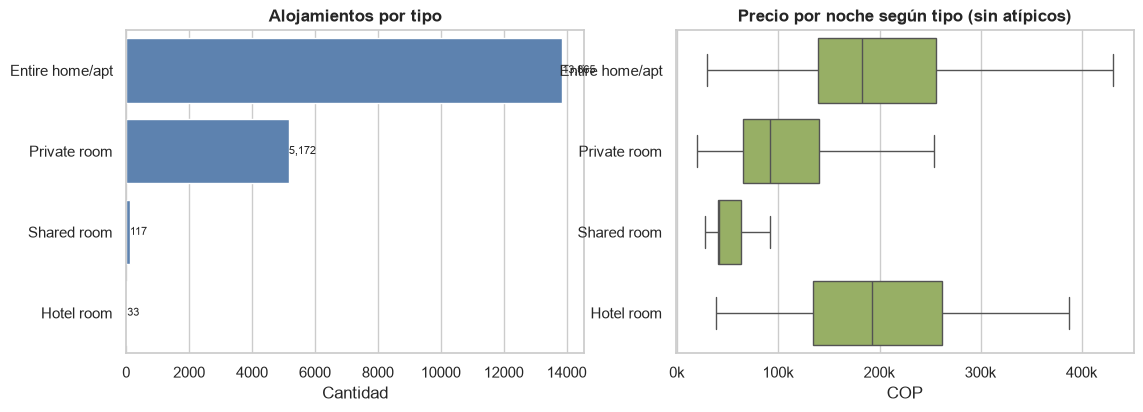

room_type
Entire home/apt    $182.589
Hotel room         $193.048
Private room        $91.295
Shared room         $41.453
Name: precio, dtype: str

In [23]:
dfp = listings.assign(precio=precio)
orden = dfp["room_type"].value_counts().index
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.countplot(data=dfp, y="room_type", order=orden, ax=axes[0], color="#4f81bd")
axes[0].set_title("Alojamientos por tipo"); axes[0].set_xlabel("Cantidad"); axes[0].set_ylabel("")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="{:,.0f}", fontsize=8)
sns.boxplot(data=dfp, x="precio", y="room_type", order=orden, ax=axes[1], showfliers=False, color="#9bbb59")
axes[1].set_title("Precio por noche según tipo (sin atípicos)"); axes[1].set_xlabel("COP"); axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(lambda x, _: f"{x/1000:.0f}k")
guardar(fig, "04_room_type_precio")
plt.show()
med_tipo = dfp.groupby("room_type")["precio"].median()
metricas["room_type"] = {k: {"n": int(v), "mediana_precio": float(med_tipo[k])}
                         for k, v in dfp["room_type"].value_counts().items()}
med_tipo.apply(cop)

**Interpretación.** La oferta está dominada por **apartamentos o casas completas (72,3 %)**, seguidos por
habitaciones privadas (27 %); las habitaciones compartidas y de hotel son marginales. La mediana del
alojamiento completo (≈ $183 mil) **duplica** la de la habitación privada (≈ $91 mil), así que el tipo de
habitación es la primera variable para segmentar el precio.

### Precio por localidad (barrio)

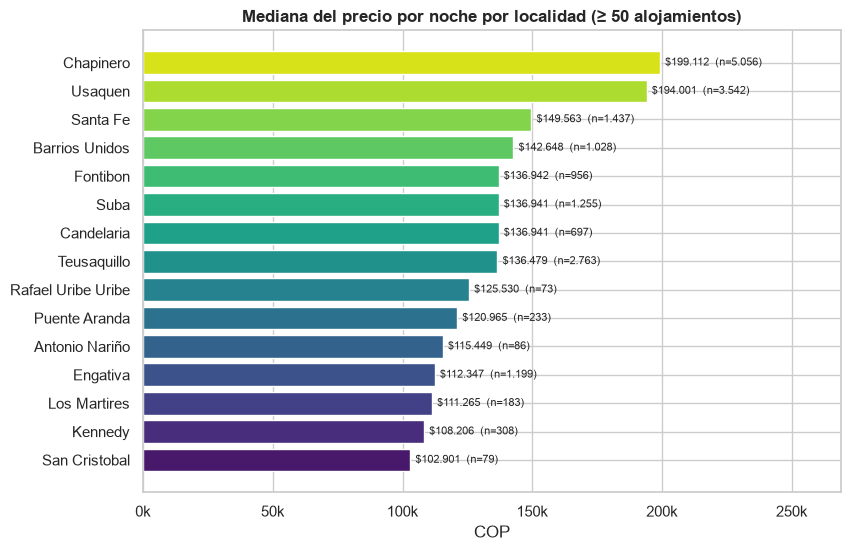

In [24]:
por_barrio = (dfp.groupby("neighbourhood_cleansed")["precio"].agg(["median", "count"])
              .query("count >= 50").sort_values("median"))
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(por_barrio.index, por_barrio["median"], color=sns.color_palette("viridis", len(por_barrio)))
for i, (m, n) in enumerate(zip(por_barrio["median"], por_barrio["count"])):
    ax.text(m + 2000, i, f"{cop(m)}  (n={n:,})".replace(",", "."), va="center", fontsize=8)
ax.set_title("Mediana del precio por noche por localidad (≥ 50 alojamientos)")
ax.set_xlabel("COP"); ax.xaxis.set_major_formatter(lambda x, _: f"{x/1000:.0f}k")
ax.set_xlim(0, por_barrio["median"].max() * 1.35)
guardar(fig, "05_precio_localidad")
plt.show()
metricas["localidades"] = por_barrio.sort_values("count", ascending=False).round(0).to_dict("index")

**Interpretación.** **Chapinero (5.097 anuncios) y Usaquén (3.582)** concentran el 45 % de la oferta (en la
gráfica, `n` cuenta solo los anuncios con precio publicado) y tienen las
medianas más altas (≈ $199 mil y $194 mil): son las zonas de negocios, vida nocturna y embajadas del norte de
la ciudad. Les siguen Santa Fe y La Candelaria (centro histórico y turístico) y Teusaquillo. Las localidades
del sur y del occidente (Kennedy, Engativá, Los Mártires) tienen menos oferta y medianas ≈ 45 % más bajas.
La ubicación es el segundo eje de segmentación del precio.

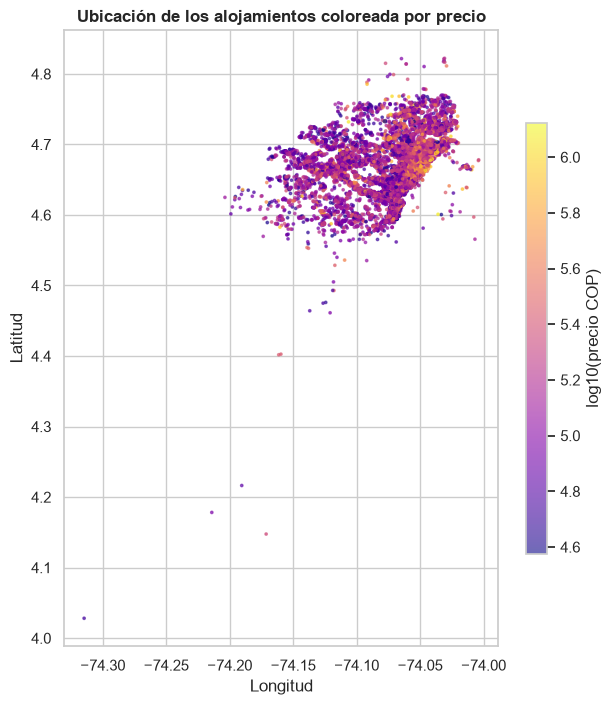

In [25]:
fig, ax = plt.subplots(figsize=(7, 8))
m = dfp[dfp["precio"].between(precio.quantile(.01), precio.quantile(.99))]
sc = ax.scatter(m["longitude"], m["latitude"], c=np.log10(m["precio"]), cmap="plasma", s=3, alpha=.6)
cb = plt.colorbar(sc, ax=ax, shrink=.7); cb.set_label("log10(precio COP)")
ax.set_title("Ubicación de los alojamientos coloreada por precio"); ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
guardar(fig, "06_mapa_precio")
plt.show()

**Interpretación.** El mapa muestra la oferta concentrada en un corredor norte–centro sobre el oriente de la
ciudad (Chapinero, Usaquén, Teusaquillo y Centro) y los colores más cálidos, es decir los precios más altos,
en el nororiente. El sur y el occidente tienen pocos puntos y tonos fríos.

### Correlaciones entre variables numéricas

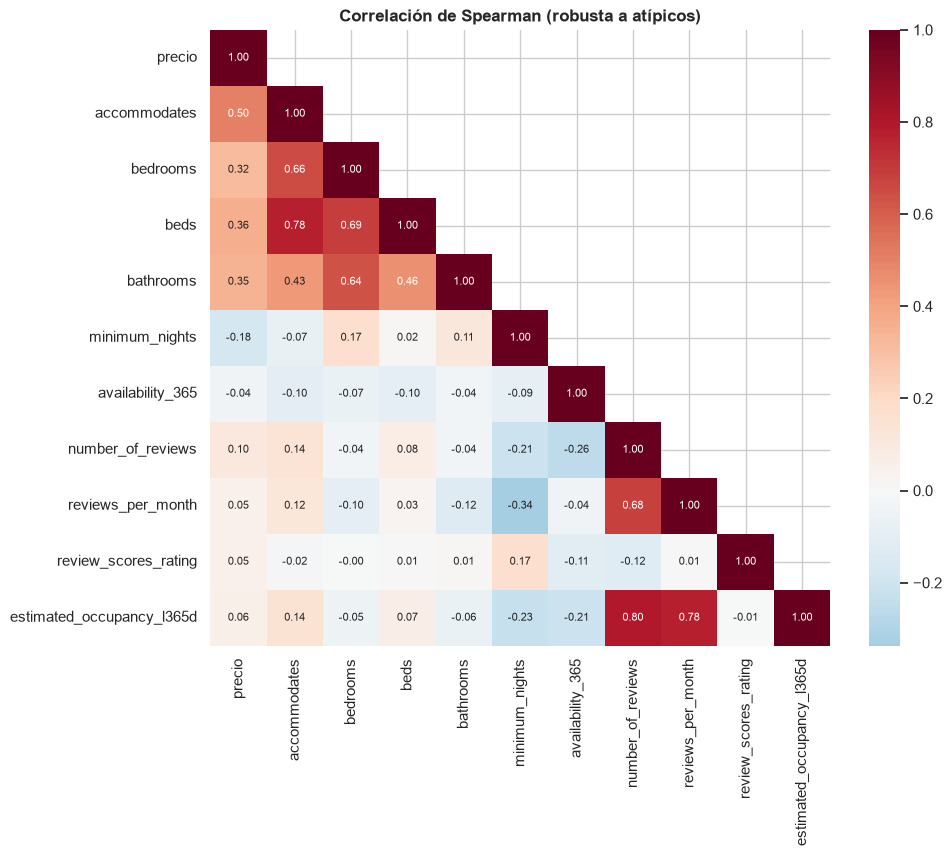

In [26]:
num = ["precio", "accommodates", "bedrooms", "beds", "bathrooms", "minimum_nights", "availability_365",
       "number_of_reviews", "reviews_per_month", "review_scores_rating", "estimated_occupancy_l365d"]
corr = dfp[num].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, annot_kws={"size": 8},
            mask=np.triu(np.ones_like(corr, dtype=bool), k=1))
ax.set_title("Correlación de Spearman (robusta a atípicos)")
guardar(fig, "07_correlaciones")
plt.show()
metricas["corr_precio"] = corr["precio"].drop("precio").round(2).to_dict()

**Interpretación.** Se usa **Spearman** porque el precio tiene atípicos extremos que distorsionarían a Pearson.

- El precio se relaciona sobre todo con la **capacidad**: `accommodates` 0,50, `beds` 0,36, `bathrooms` 0,35 y
  `bedrooms` 0,32. Las variables de capacidad están correlacionadas entre sí (0,43–0,78; la más alta es
  `accommodates`–`beds`), así que un modelo de precio no necesita todas.
- La calificación (`review_scores_rating`, 0,05) y el número de reseñas casi **no influyen en el precio**.
- `minimum_nights` tiene una relación negativa débil (−0,18): los anuncios de estancia mensual cobran menos
  por noche.
- `number_of_reviews` y `estimated_occupancy_l365d` están muy correlacionadas (0,80). Esto confirma que
  Inside Airbnb estima la ocupación a partir de las reseñas, así que no son variables independientes.

### Amenities más frecuentes

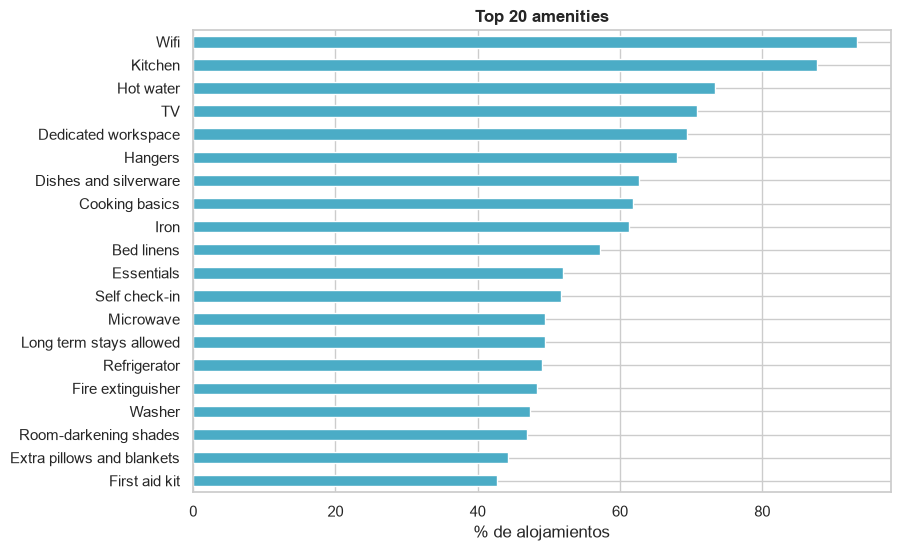

In [27]:
top_amen = pd.Series(dict(conteo_amen.most_common(20))) / len(listings) * 100
fig, ax = plt.subplots(figsize=(9, 6))
top_amen.sort_values().plot.barh(ax=ax, color="#4bacc6")
ax.set_xlabel("% de alojamientos"); ax.set_title("Top 20 amenities")
guardar(fig, "08_top_amenities")
plt.show()
metricas["top_amenities_pct"] = top_amen.round(1).to_dict()

**Interpretación.** Wifi (93 %) y cocina (88 %) son prácticamente universales y ya **no diferencian** un
anuncio de otro. Destacan *Dedicated workspace* (69 %) y *Long term stays allowed* (49 %), que muestran una
oferta orientada al **trabajo remoto y a estancias largas**, coherente con el pico de 30 noches mínimas.

### Evolución de las reseñas (proxy de demanda)

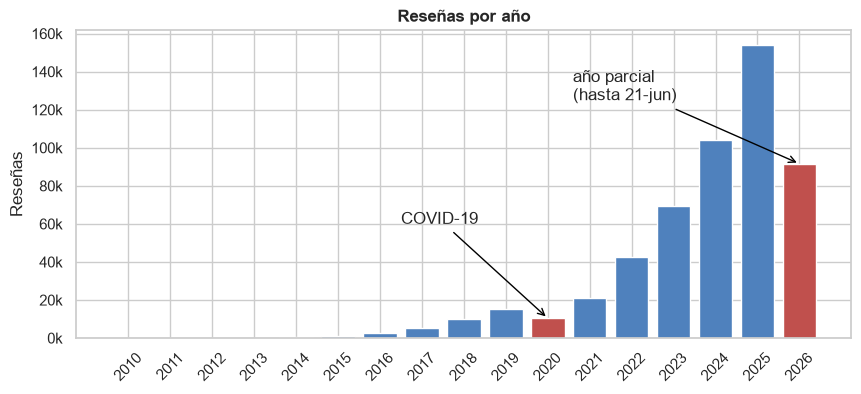

In [28]:
anio_rev = pd.to_datetime(reviews["date"]).dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(anio_rev.index, anio_rev.values, color=["#c0504d" if a in (2020, 2026) else "#4f81bd" for a in anio_rev.index])
ax.set_title("Reseñas por año"); ax.set_ylabel("Reseñas")
ax.yaxis.set_major_formatter(lambda x, _: f"{x/1000:.0f}k")
ax.annotate("COVID-19", (2020, anio_rev[2020]), xytext=(2016.5, 60000),
            arrowprops={"arrowstyle": "->", "color": "black"})
ax.annotate("año parcial\n(hasta 21-jun)", (2026, anio_rev[2026]), xytext=(2020.6, 125000),
            arrowprops={"arrowstyle": "->", "color": "black"})
ax.set_xticks(anio_rev.index)
ax.tick_params(axis="x", rotation=45)
guardar(fig, "09_reviews_por_anio")
plt.show()
metricas["reviews_por_anio"] = {int(k): int(v) for k, v in anio_rev.items()}

**Interpretación.** Las reseñas crecen de forma casi exponencial desde 2014. La única caída es en **2020
(−31 % frente a 2019) por la pandemia**, y desde 2021 la recuperación es fuerte: en **2025 hubo 154 mil
reseñas, 10 veces más que en 2019**. 2026 solo cubre hasta el 21 de junio, pero ya suma 91 mil, en línea
para superar a 2025. Bogotá es un mercado en expansión. Para comparar meses entre años hay que usar las
variables `anio` y `mes` derivadas, sin olvidar que 2026 es parcial.

### Disponibilidad futura según el calendario

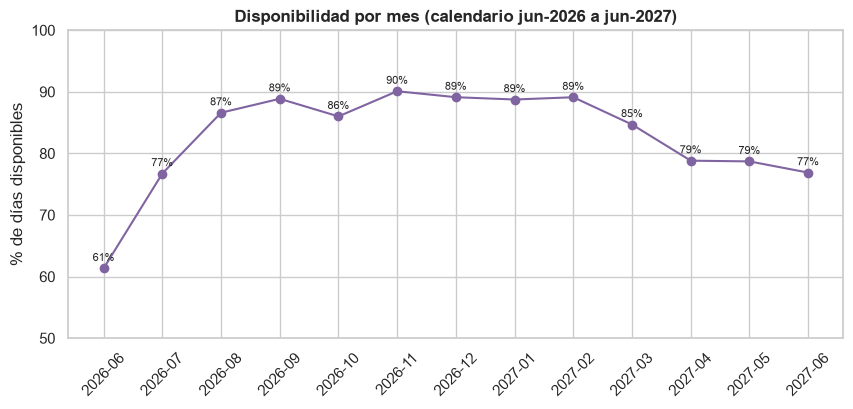

In [29]:
disp_mes = cal.groupby(cal["fecha"].dt.to_period("M"))["disp"].mean().mul(100)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(disp_mes.index.astype(str), disp_mes.values, marker="o", color="#8064a2")
ax.set_ylim(50, 100); ax.set_ylabel("% de días disponibles"); ax.set_title("Disponibilidad por mes (calendario jun-2026 a jun-2027)")
for x, y in zip(disp_mes.index.astype(str), disp_mes.values):
    ax.text(x, y + 1.2, f"{y:.0f}%", ha="center", fontsize=8)
plt.xticks(rotation=45)
guardar(fig, "10_disponibilidad_mensual")
plt.show()
metricas["disponibilidad_mensual"] = {str(k): round(float(v), 1) for k, v in disp_mes.items()}
metricas["disponibilidad_global"] = round(float(cal["disp"].mean() * 100), 1)

In [30]:
dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
disp_dia = cal.groupby(cal["fecha"].dt.dayofweek)["disp"].mean().mul(100).round(1)
disp_dia.index = dias
metricas["disponibilidad_dia_semana"] = disp_dia.to_dict()
disp_dia.to_frame("% días disponibles")

,% días disponibles
Lunes,84.1
Martes,84.6
Miércoles,84.5
Jueves,84.0
Viernes,83.6
Sábado,83.7
Domingo,84.3


**Interpretación.** En promedio el **84 % de los días futuros está disponible**. Los meses más cercanos
(junio 61 %, julio 77 %) muestran menos disponibilidad porque ya acumulan reservas, mientras que de agosto a
febrero se mantiene cerca del 86–90 %. Esto es típico del calendario de Airbnb: las reservas se concentran
a corto plazo, y la "no disponibilidad" lejana corresponde sobre todo a **bloqueos del anfitrión**. Por eso
`tasa_no_disponible` debe leerse como un **proxy** de ocupación y no como ocupación real. Por día de la
semana la diferencia es mínima (83,6–84,6 %), así que el calendario no muestra un patrón fin de semana /
entre semana.

## Resumen de hallazgos y decisiones para la transformación

**Inconsistencias y variables problemáticas**

1. `price` está como texto con `$` y `,`, y su distribución es extremadamente sesgada: mediana $161 mil, máximo
   $448 millones, 27 anuncios por encima de $10 millones (errores del anfitrión) y 195 sin precio.
2. Faltan 13 columnas que llegan completamente vacías en este scrape. No hay datos de tiempo o tasa de
   respuesta del anfitrión ni de `host_since`.
3. `amenities` y `price_quote_raw` son JSON anidados guardados como texto.
4. Los datos del anfitrión se repiten en cada alojamiento: 8.335 anfitriones, uno de ellos con 166 anuncios.
5. Las fechas están como texto y el calendario tiene 7 millones de filas sin precio diario.
6. Hay texto inconsistente ("Bogota"/"Bogotá") y 69 mil comentarios con HTML.
7. El 22 % de los alojamientos no tiene reseñas, de ahí los nulos de calificaciones y fechas de reseña.

**Correlaciones y patrones relevantes:** el precio depende de la capacidad (ρ≈0,5), del tipo de alojamiento y
de la localidad (norte–oriente más caro). La calificación no explica el precio. La demanda, medida por las
reseñas, crece fuerte después del COVID, y una parte importante de la oferta apunta a estancias de 30 noches
o más.

**Decisiones que impactan la transformación (implementadas en `src/transformacion.py`):**

| Hallazgo | Transformación |
|---|---|
| Precio en texto | `normalizar_precio`: quita `$` y `,` y convierte a float (COP) |
| Precio sesgado y con atípicos | `categorizar_precio` por rangos fijos + `marcar_outliers_iqr` (se marcan, no se borran) |
| Nulos con significado | `tratar_nulos_listings`: medianas por `room_type`, `"Sin información"`, `"Sin registro"`, flags `tiene_reviews` y `tiene_licencia` |
| Columnas vacías y URLs | `eliminar_columnas_sin_valor` |
| `bathrooms` incompleto | `convertir_banos` desde `bathrooms_text` + `bano_compartido` |
| JSON anidados | `desanidar_amenities` (tabla `listing_amenities`) y `desanidar_price_quote` |
| Anfitrión repetido | `extraer_hosts` (dimensión `hosts`) |
| Fechas en texto | `estandarizar_fechas` (`YYYY-MM-DD`) + `derivar_variables_fecha` |
| Calendario muy granular | `transformar_calendario`: `calendar_mensual` y `calendar_semanal` |
| Texto inconsistente | `limpiar_texto`, barrios en formato título, "Bogota"→"Bogotá" |
| `t`/`f` | `convertir_booleanos` |
| Duplicados (0 hoy) | `limpiar_duplicados` por clave natural, como control |

In [31]:
(RAIZ / "informe" / "metricas_eda.json").write_text(json.dumps(metricas, ensure_ascii=False, indent=2, default=str),
                                                    encoding="utf-8")
print("Métricas guardadas para el informe:", list(metricas))

Métricas guardadas para el informe: ['registros', 'columnas', 'nulos_listings_pct', 'duplicados', 'precio', 'minimum_nights', 'amenities_distintas', 'amenities_mediana', 'hosts', 'texto', 'room_type', 'localidades', 'corr_precio', 'top_amenities_pct', 'reviews_por_anio', 'disponibilidad_mensual', 'disponibilidad_global', 'disponibilidad_dia_semana']
